📊 Country Ranking (Growth 2023 → 2028)
Year     Growth_2023_2028
Country                  
IRQ             13.698799
SD               7.800012
YEM              5.260812
DZA              4.477413
QAT              4.369597
LBY              3.869376
KWT              1.472934
MAR              0.790172
KSA             -0.540528
BHR             -1.291984
LBN             -3.632529
JOR             -4.664910
UEA             -5.396485
OMN             -6.005509
EGY             -6.639309

=== Country Growth Ranking (by CAGR 2023→2028, XGB) ===
   Country    Base_2023       F_2028  Pct_Growth_2023_2028  CAGR_2023_2028_%
0      IRQ   85022590.0   96669664.0             13.698799          2.600901
1       SD    6689188.0    7210945.5              7.800012          1.513491
2      YEM   12217923.0   12860685.0              5.260812          1.030696
3      DZA   41456524.0   43312704.0              4.477413          0.879863
4      QAT   31431140.0   32804554.0              4.369597          0.859033


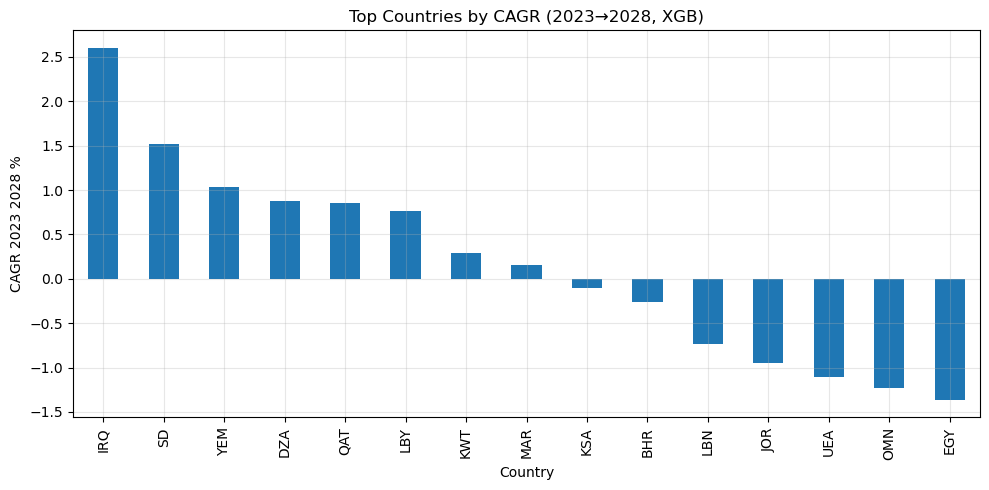

C:\Users\chaud\AppData\Local\Temp\ipykernel_36748\851828066.py:155: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


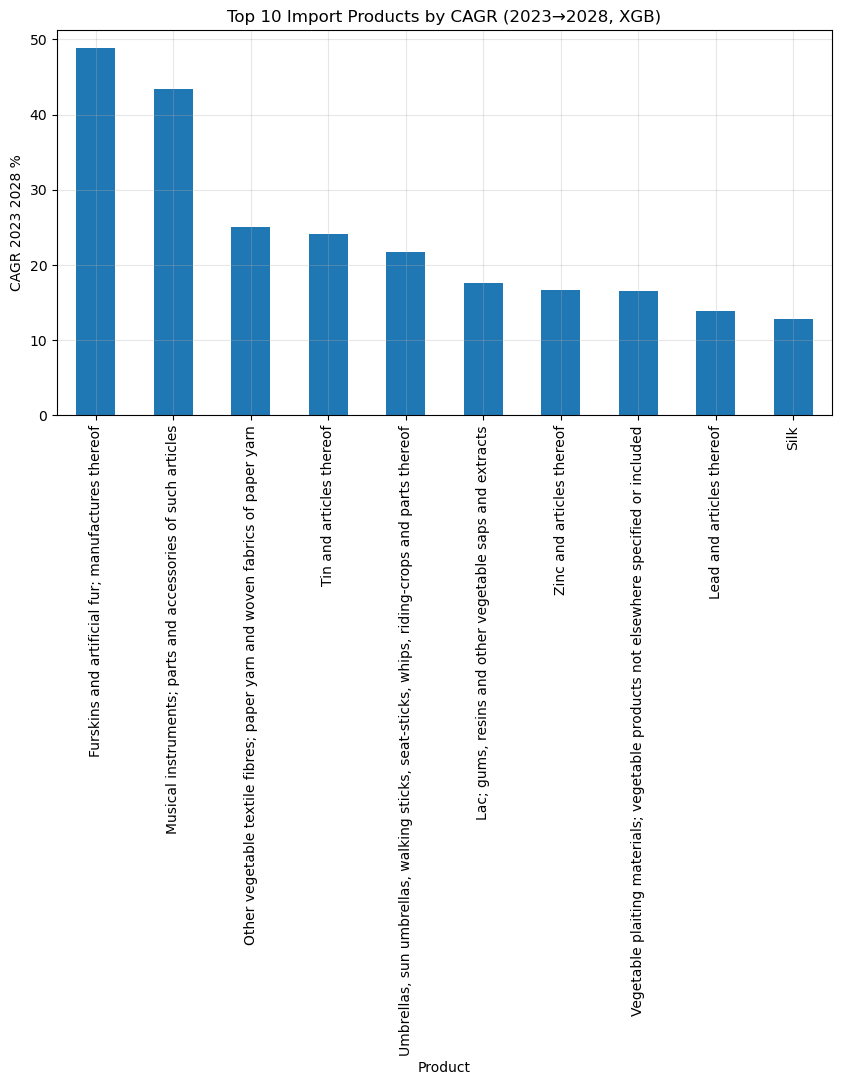

[skip plot] Nothing to plot for: Top 10 Export Products by CAGR (2023→2028, XGB)


KeyError: 'Growth_2023_2028'

<Figure size 1000x500 with 0 Axes>

In [2]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ===========================
# 1. Load dataset
# ===========================
df = pd.read_csv("C:\\Users\\chaud\\Downloads\\cleaned_trade_master (1).csv")

# Drop rows with missing target
df = df.dropna(subset=["Value_2023"])

# ===========================
# 2. Features & Target
# ===========================
features = ["Trade_Balance_2023","Growth_2019_2023","Growth_2022_2023",
            "World_Growth","World_Import_Rank","Avg_Distance_km",
            "Concentration","World_Import_Share","Avg_Tariff"]

X = df[features]
y = df["Value_2023"]

# ===========================
# 3. Train XGBoost Model
# ===========================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb = XGBRegressor(
    n_estimators=400, learning_rate=0.07, max_depth=6,
    subsample=0.9, colsample_bytree=0.9, random_state=42
)

xgb.fit(X_train, y_train)

# ===========================
# 4. Forecast Future Years (2024–2028)
# ===========================
future_years = [2024, 2025, 2026, 2027, 2028]
df_forecasts = []

for year in future_years:
    preds = xgb.predict(df[features])
    temp = df[["Country","Product","Direction"]].copy()
    temp["Year"] = year
    temp["Forecast_Value"] = preds
    df_forecasts.append(temp)

forecast_df = pd.concat(df_forecasts)

# ===========================
# 5. Country-level Growth Ranking
# ===========================
country_growth = (
    forecast_df.groupby(["Country","Year"])["Forecast_Value"].sum().reset_index()
    .pivot(index="Country", columns="Year", values="Forecast_Value")
)

country_growth["Growth_2023_2028"] = (
    (country_growth[2028] - df.groupby("Country")["Value_2023"].sum()) /
    df.groupby("Country")["Value_2023"].sum()
) * 100

country_rank = country_growth[["Growth_2023_2028"]].sort_values("Growth_2023_2028", ascending=False)

print("📊 Country Ranking (Growth 2023 → 2028)")
print(country_rank)

# ===========================
# 6. Product-level Growth Ranking
# ===========================
# Normalize Direction labels (capitalize first letter)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assumptions:
# - df: your original rows with at least ['Country','Product','Direction','Value_2023']
# - forecast_df: rows with ['Country','Product','Direction','Year','Forecast_Value'] for 2024..2028 (XGB)
# If you also have Linear forecasts, ignore them here; we’ll use XGB only for ranking.

# 0) Normalize Direction (avoid Import/export key errors)
df["Direction"] = df["Direction"].astype(str).str.strip().str.capitalize()
forecast_df["Direction"] = forecast_df["Direction"].astype(str).str.strip().str.capitalize()

# 1) Country-level growth ranking (Total)
base_country_2023 = df.groupby("Country", as_index=False)["Value_2023"].sum().rename(columns={"Value_2023":"Base_2023"})
xgb_country = (forecast_df.groupby(["Country","Year"], as_index=False)["Forecast_Value"].sum())

# Keep 2028 only for ranking; join base 2023
xgb_2028 = xgb_country[xgb_country["Year"]==2028].drop(columns="Year").rename(columns={"Forecast_Value":"F_2028"})
country_rank = xgb_2028.merge(base_country_2023, on="Country", how="left")

# % Growth and CAGR (handle zeros safely)
country_rank["Pct_Growth_2023_2028"] = np.where(
    country_rank["Base_2023"]>0,
    (country_rank["F_2028"] / country_rank["Base_2023"] - 1.0) * 100.0,
    np.nan
)
country_rank["CAGR_2023_2028_%"] = np.where(
    country_rank["Base_2023"]>0,
    ((country_rank["F_2028"] / country_rank["Base_2023"])**(1/5) - 1.0) * 100.0,
    np.nan
)

country_rank = country_rank.sort_values("CAGR_2023_2028_%", ascending=False).reset_index(drop=True)
print("\n=== Country Growth Ranking (by CAGR 2023→2028, XGB) ===")
print(country_rank[["Country","Base_2023","F_2028","Pct_Growth_2023_2028","CAGR_2023_2028_%"]])

# 2) Product-level growth (separate Import vs Export)
base_prod = (df.groupby(["Product","Direction"], as_index=False)["Value_2023"].sum()
               .rename(columns={"Value_2023":"Base_2023"}))
xgb_prod = (forecast_df.groupby(["Product","Direction","Year"], as_index=False)["Forecast_Value"].sum())
xgb_prod_2028 = xgb_prod[xgb_prod["Year"]==2028].drop(columns="Year").rename(columns={"Forecast_Value":"F_2028"})

prod_rank = xgb_prod_2028.merge(base_prod, on=["Product","Direction"], how="left")
prod_rank["Pct_Growth_2023_2028"] = np.where(
    prod_rank["Base_2023"]>0,
    (prod_rank["F_2028"] / prod_rank["Base_2023"] - 1.0) * 100.0,
    np.nan
)
prod_rank["CAGR_2023_2028_%"] = np.where(
    prod_rank["Base_2023"]>0,
    ((prod_rank["F_2028"] / prod_rank["Base_2023"])**(1/5) - 1.0) * 100.0,
    np.nan
)

# Split safely (Direction might not have both values)
imports_mask = prod_rank["Direction"].eq("Import")
exports_mask = prod_rank["Direction"].eq("Export")

top10_import_products = (prod_rank[imports_mask]
                         .sort_values("CAGR_2023_2028_%", ascending=False)
                         .head(10))
top10_export_products = (prod_rank[exports_mask]
                         .sort_values("CAGR_2023_2028_%", ascending=False)
                         .head(10))

print("\n=== Top 10 Import Products by CAGR (XGB) ===")
print(top10_import_products[["Product","Base_2023","F_2028","Pct_Growth_2023_2028","CAGR_2023_2028_%"]])

print("\n=== Top 10 Export Products by CAGR (XGB) ===")
print(top10_export_products[["Product","Base_2023","F_2028","Pct_Growth_2023_2028","CAGR_2023_2028_%"]])

# 3) Optional: Plots with guards so they don’t crash when empty
def _barplot(df_in, value_col, title, fname=None):
    if df_in is None or df_in.empty or value_col not in df_in.columns:
        print(f"[skip plot] Nothing to plot for: {title}")
        return
    ax = df_in.set_index(df_in.columns[0])[value_col].plot(kind="bar", figsize=(10,5))
    ax.set_ylabel(value_col.replace("_", " "))
    ax.set_title(title)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=140)
    plt.show()

# Top 15 countries by CAGR
_barplot(country_rank.head(15)[["Country","CAGR_2023_2028_%"]],
         "CAGR_2023_2028_%",
         "Top Countries by CAGR (2023→2028, XGB)",
         "rank_countries_cagr.png")

# Top 10 import products by CAGR
_barplot(top10_import_products[["Product","CAGR_2023_2028_%"]],
         "CAGR_2023_2028_%",
         "Top 10 Import Products by CAGR (2023→2028, XGB)",
         "rank_import_products_cagr.png")

# Top 10 export products by CAGR
_barplot(top10_export_products[["Product","CAGR_2023_2028_%"]],
         "CAGR_2023_2028_%",
         "Top 10 Export Products by CAGR (2023→2028, XGB)",
         "rank_export_products_cagr.png")



# ===========================
# 7. Optional Visualization
# ===========================
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
country_rank["Growth_2023_2028"].head(10).plot(kind="bar", color="skyblue")
plt.title("Top Countries by Growth Potential (2023→2028)")
plt.ylabel("% Growth")
plt.show()

plt.figure(figsize=(10,5))
top_imports["Growth_2023_2028"].plot(kind="bar", color="orange")
plt.title("Top 10 Import Products Growth (2023→2028)")
plt.ylabel("% Growth")
plt.show()

plt.figure(figsize=(10,5))
top_exports["Growth_2023_2028"].plot(kind="bar", color="green")
plt.title("Top 10 Export Products Growth (2023→2028)")
plt.ylabel("% Growth")
plt.show()
